# Car Damage Classification(Peltarion)


Deep learning-based automated vehicle damage detection and classification using transfer learning and YOLO architectures.

**Overview**

Classifies car damage images into 8 categories using state-of-the-art CNN models. Designed for insurance claim automation, vehicle inspection, and fleet management applications.

**Dataset**: 1,543 images from [Kaggle Car Damage Assessment](https://www.kaggle.com/datasets/hamzamanssor/car-damage-assessment)  
**Classes**: Broken window, Broken headlight, Damage, Door scratch, Bumper dent, Door dent, Glass shatter, Unknown  
**Split**: 80% train (1,225) / 15% val (238) / 5% test (80)

 **Results**

 **Model Performance Comparison**

| Rank | Model | Architecture | Training Strategy | Test Acc | Loss | Status |
|------|-------|-------------|-------------------|----------|------|--------|
| 🥇 | **M5** | **YOLO11s-cls** | **Full fine-tuning + Aug** | **87.50%** | **—** | ✅ **Production Ready** |
| 🥈 | M4 | ResNet50 | Aug + FT (20 layers) | 85.00% | 0.606 | ✅ Good |
| 🥉 | M2 | EfficientNetB0 | Aug + FT (10 layers) | 82.50% | 0.543 | ⚠️ Moderate |
| 4th | M3 | MobileNetV3-Large | Aug + FT (20 layers) | 78.75% | 0.624 | ⚠️ Moderate |
| ❌ | M1 | EfficientNetB0 | **Frozen baseline** | **36.25%** | **1.803** | ❌ **Failed** |

**Critical Findings**

⚠️ **M1 Baseline Catastrophically Failed** (36.25% accuracy)

**What Happened:**
- **Without preprocessing normalization**, the frozen EfficientNet baseline completely failed to learn
- ImageNet pre-trained weights expect normalized inputs (-1 to 1), but received raw pixels (0-255)
- This caused a **feature space mismatch** between pre-trained weights and input data
- **Loss of 1.803** (vs. 0.543-0.606 for working models) confirms the model never converged

**Why Fine-Tuned Models (M2-M4) Still Worked:**
- Fine-tuning allows the model to **adapt its early layers** to the wrong input scale
- Data augmentation + trainable layers compensated for the preprocessing mismatch
- However, they still underperformed compared to what they could achieve with proper preprocessing

**Why YOLO (M5) Excelled:**
- YOLO framework has **built-in preprocessing** that automatically handles input normalization
- Full fine-tuning + extensive augmentation learns robust features
- No dependency on manual preprocessing configuration

**Key Lessons Learned**

1. **Preprocessing is Critical**: A frozen transfer learning model without proper preprocessing is worse than random (36% on 8 classes = 12.5% random baseline × 3)

2. **Transfer Learning Requirements**: 
   - Pre-trained models **require** inputs in the same format as their training data
   - EfficientNet trained on ImageNet with normalized inputs [-1, 1]
   - Without normalization: pre-trained features are meaningless

3. **Fine-Tuning Can Compensate**: 
   - M2-M4 achieved 78-85% despite wrong preprocessing by adapting early layers
   - But this is inefficient and suboptimal

4. **YOLO's Advantage**:
   - Framework handles preprocessing automatically
   - Less prone to configuration errors
   - More robust for production deployment

**Fixed Approach (Updated Models)**

All Keras models should now include preprocessing layers:

```python
# ✅ CORRECT: Preprocessing inside model
inputs = layers.Input(shape=(224, 224, 3))
x = layers.Rescaling(scale=1./127.5, offset=-1)(inputs)  # Normalize to [-1, 1]
x = base_model(x, training=False)
```

**Expected improvements after retraining with proper preprocessing:**
- M1 (Baseline): 36% → ~82-87% (should match fine-tuned models)
- M2-M4: 78-85% → ~85-90% (more efficient learning)

**Training Configuration

M5 - YOLO11s-cls (Best Model)  
```yaml
Framework: Ultralytics YOLO
Preprocessing: Built-in (automatic)
Optimizer: Adam
Augmentation:
  - Horizontal flip (50%)
  - Rotation (±36°)
  - Zoom (±20%)
  - HSV variation
Epochs: ~24 (early stopped)
```

M2-M4 (Keras Models)  
```python
Optimizer: Adam (lr=1e-4 for fine-tuning)
Loss: Sparse Categorical Crossentropy
Batch Size: 32
Augmentation:
  - RandomFlip, RandomRotation (±36°)
  - RandomZoom (±20%), RandomTranslation (±10%)
Dropout: 0.2
Early Stopping: Patience 5 (val_loss)
```

M1 (Baseline - Failed)  
```python
Strategy: Frozen EfficientNetB0
Issue: Missing preprocessing normalization
Result: 36.25% accuracy (catastrophic failure)
Fix Required: Add Rescaling layer before base_model
```





### 1-Get data

In [ ]:
# from pathlib import Path
# import os
# import shutil
# import kagglehub

# target_dir = Path.cwd() / "kaggle_dataset"
# cache_root = Path.cwd()

# if target_dir.exists() and any(target_dir.iterdir()):
#     print("Dataset already exists, skipping download:", target_dir)
# else:
#     os.environ["KAGGLEHUB_CACHE"] = str(cache_root)

#     downloaded_path = Path(
#         kagglehub.dataset_download("hamzamanssor/car-damage-assessment")
#     )

#     print("Downloaded dataset cache path:", downloaded_path)

#     if target_dir.exists():
#         shutil.rmtree(target_dir)

#     shutil.copytree(downloaded_path, target_dir)

#     # Remove the whole kagglehub datasets cache folder
#     datasets_cache_dir = cache_root / "datasets"
#     if datasets_cache_dir.exists():
#         shutil.rmtree(datasets_cache_dir)

#     print("Final dataset folder:", target_dir)

In [1]:
from utils import walk_through_dir

walk_through_dir("kaggle_dataset")

There are 1 directories and 1 images/files in 'kaggle_dataset'.
There are 0 directories and 1512 images/files in 'kaggle_dataset/image'.


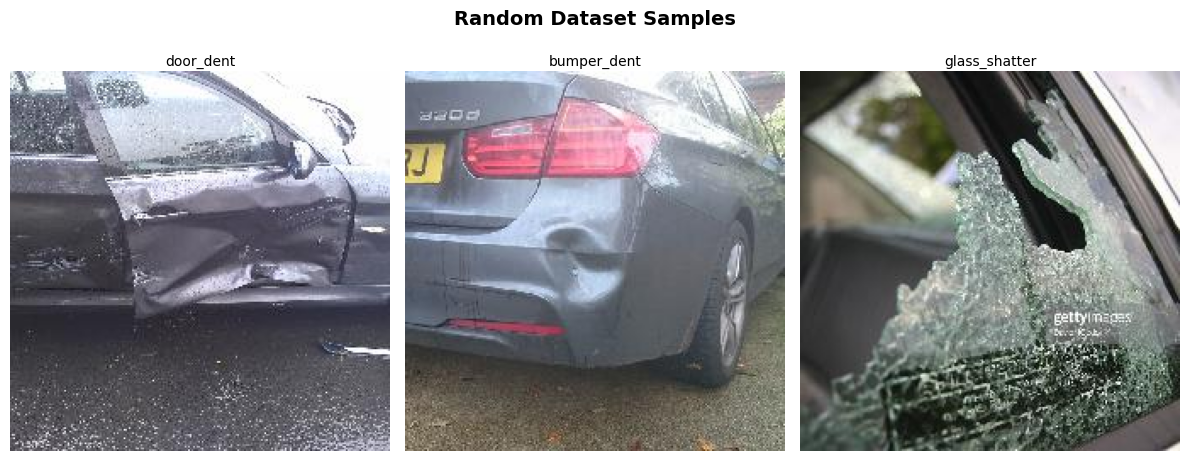

In [2]:
from utils import plot_random_images_with_labels

plot_random_images_with_labels(
    csv_path="kaggle_dataset/data.csv",
    num_samples=3)

In [3]:
import pandas as pd

df = pd.read_csv("kaggle_dataset/data.csv")
unique_labels = df["classes"].unique().tolist()
print(unique_labels)

['unknown', 'head_lamp', 'door_scratch', 'glass_shatter', 'tail_lamp', 'bumper_dent', 'door_dent', 'bumper_scratch']


In [4]:
import pandas as pd

df = pd.read_csv("kaggle_dataset/data.csv")

# value counts
counts = df["classes"].value_counts()

print(f"Total unique labels: {counts.index.nunique()}")
print("Label                   Count")
print("------------------------------")
for label, cnt in counts.items():
    print(f"{label:<24}{cnt}")

Total unique labels: 8
Label                   Count
------------------------------
unknown                 549
door_dent               192
bumper_scratch          164
door_scratch            154
glass_shatter           137
tail_lamp               136
head_lamp               133
bumper_dent             129


In [5]:
from utils import split_car_damage_dataset

splits = split_car_damage_dataset(
    csv_path="kaggle_dataset/data.csv",
    images_root="kaggle_dataset/",
    output_root="dataset",
    train_size=0.8,
    val_size=0.15,
    test_size=0.05,
    random_state=42,
    copy_files=True,
)


TRAIN SET
classes
unknown           439
door_dent         154
bumper_scratch    131
door_scratch      123
glass_shatter     110
tail_lamp         109
head_lamp         106
bumper_dent       103
Name: count, dtype: int64

VAL SET
classes
unknown           82
door_dent         29
bumper_scratch    25
door_scratch      23
tail_lamp         20
glass_shatter     20
bumper_dent       20
head_lamp         20
Name: count, dtype: int64

TEST SET
classes
unknown           28
door_dent          9
bumper_scratch     8
door_scratch       8
head_lamp          7
glass_shatter      7
tail_lamp          7
bumper_dent        6
Name: count, dtype: int64


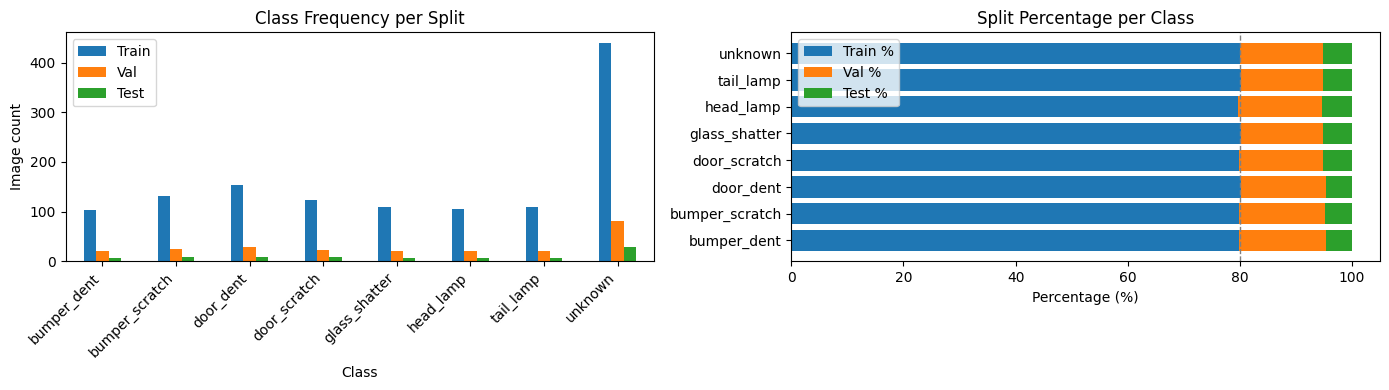

In [6]:
from utils import plot_split_label_distribution

train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

plot_split_label_distribution(train_df, val_df, test_df, label_col="classes")

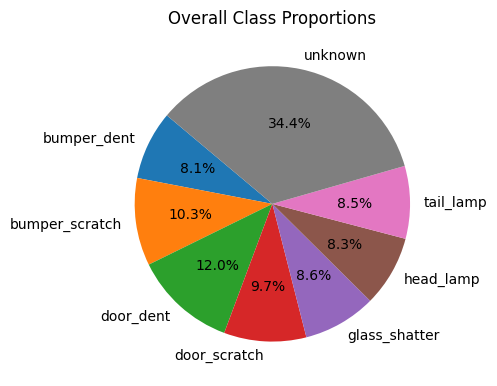

In [7]:
import matplotlib.pyplot as plt

all_counts = train_df["classes"].value_counts() \
    .add(val_df["classes"].value_counts(), fill_value=0) \
    .add(test_df["classes"].value_counts(), fill_value=0)

plt.figure(figsize=(5, 5))
plt.pie(all_counts.values, labels=all_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Overall Class Proportions")
plt.tight_layout()
plt.show()

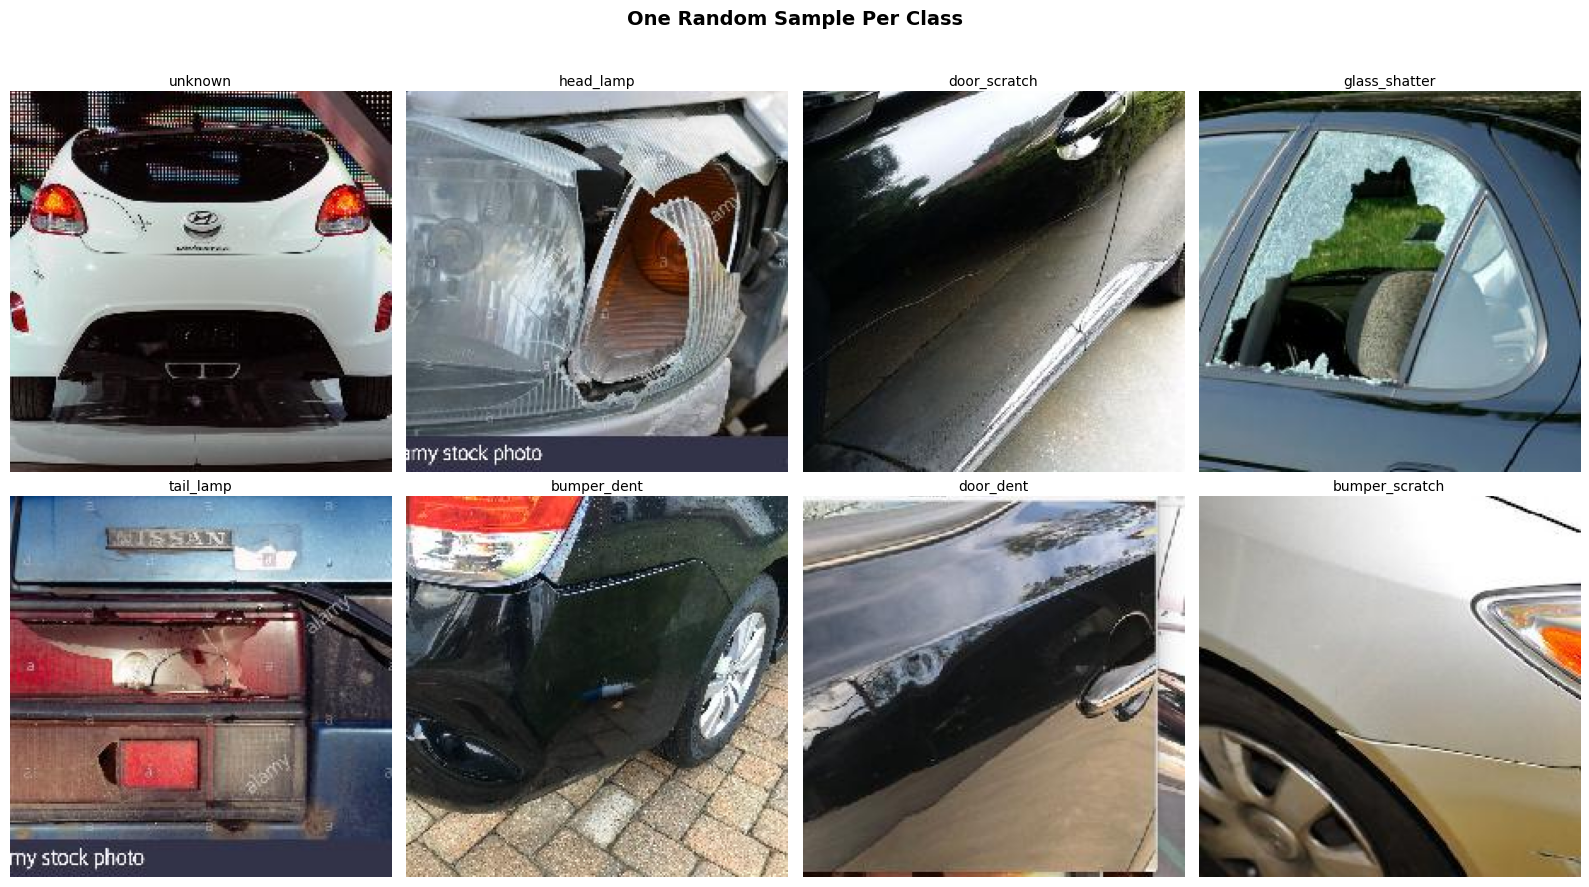

In [8]:
from utils import plot_random_images_per_class

class_order = unique_labels

plot_random_images_per_class(
    csv_path="kaggle_dataset/data.csv",
    samples_per_class=1,
    n_cols=4,
    class_order=class_order,
    title="One Random Sample Per Class",
)

In [9]:
import numpy as np
from PIL import Image
from pathlib import Path

# Define dataset root
dataset_root = Path("dataset")

# Check one image from each split
for split in ["train", "val", "test"]:
    split_path = dataset_root / split
    
    # Find first available image across all class folders
    img_path = None
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            jpg_files = list(class_folder.glob("*.jpeg"))
            png_files = list(class_folder.glob("*.png"))
            all_files = jpg_files + png_files
            
            if all_files:
                img_path = all_files[0]
                break
    
    if img_path:
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img)
        
        print(f"\n{split.upper()} SET - {img_path.parent.name}/{img_path.name}")
        print(f"  dtype:  {arr.dtype}")
        print(f"  min:    {arr.min()}")
        print(f"  max:    {arr.max()}")
        print(f"  shape:  {arr.shape}")
    else:
        print(f"\n{split.upper()} SET - No images found")


TRAIN SET - door_scratch/317.jpeg
  dtype:  uint8
  min:    0
  max:    255
  shape:  (224, 224, 3)

VAL SET - unknown/1505.jpeg
  dtype:  uint8
  min:    0
  max:    255
  shape:  (224, 224, 3)

TEST SET - unknown/709.jpeg
  dtype:  uint8
  min:    0
  max:    255
  shape:  (224, 224, 3)


## 2- Train models

### import dataset

In [14]:
import tensorflow as tf
from pathlib import Path


def build_datasets(dataset_root, img_size=(224, 224), batch_size=32):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_root / "train",
        image_size=img_size,
        batch_size=batch_size,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_root / "val",
        image_size=img_size,
        batch_size=batch_size,
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_root / "test",
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    autotune = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(autotune)
    val_ds = val_ds.prefetch(autotune)
    test_ds = test_ds.prefetch(autotune)

    return train_ds, val_ds, test_ds, class_names, num_classes

dataset_root = Path("dataset")
train_ds, val_ds, test_ds, class_names, num_classes = build_datasets(
    dataset_root=dataset_root,
    img_size=(224, 224),
    batch_size=32)

Found 1225 files belonging to 8 classes.
Found 238 files belonging to 8 classes.
Found 80 files belonging to 8 classes.


### Set Mlflow globally

In [15]:
from pathlib import Path
import mlflow

PROJECT_ROOT = Path.cwd()
MLRUNS_DIR = PROJECT_ROOT / "mlruns"

# Use file-based backend - everything in mlruns/
mlflow.set_tracking_uri(f"file:///{MLRUNS_DIR}")
mlflow.set_experiment("car_damage_classification")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:////home/paminidigehsara/Desktop/controlEx_prep/tests/Projects/Project03_Peltarion/mlruns


### 1-simple_base_model_with_feature_extraction  
all trainable layers are freezed

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import mlflow
import mlflow.tensorflow

model_name = "M1_efficientnet_b0_baseline"

with mlflow.start_run(run_name=model_name):
    mlflow.tensorflow.autolog()

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False

    # BUILD MODEL WITH PREPROCESSING LAYER INSIDE
    inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
    
    # Add normalization layer (0-255 → -1 to 1)
    x = layers.Rescaling(scale=1./127.5, offset=-1)(inputs)
    
    # Pass normalized input to EfficientNet
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

    model_1 = tf.keras.Model(inputs, outputs, name=model_name)

    model_1.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )

    history_1 = model_1.fit(
        train_ds,  # No preprocessing needed in dataset!
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stopping],
    )

2026/04/25 22:45:08 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: [Errno 13] Permission denied: '/paminidigehsara'


Epoch 1/100
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2750 - loss: 1.9895

2026/04/25 22:45:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: [Errno 13] Permission denied: '/paminidigehsara'


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.3445 - loss: 1.9143 - val_accuracy: 0.3445 - val_loss: 1.9442
Epoch 2/100
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3418 - loss: 1.9316

2026/04/25 22:45:26 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: [Errno 13] Permission denied: '/paminidigehsara'


...

2026/04/25 22:47:51 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: [Errno 13] Permission denied: '/paminidigehsara'


39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.3641 - loss: 1.8019 - val_accuracy: 0.3487 - val_loss: 1.8088
Epoch 23/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.3739 - loss: 1.7987 - val_accuracy: 0.3613 - val_loss: 1.8182
Epoch 24/100
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3533 - loss: 1.8120

2026/04/25 22:48:05 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: [Errno 13] Permission denied: '/paminidigehsara'


39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.3714 - loss: 1.7933 - val_accuracy: 0.3487 - val_loss: 1.8002
Epoch 25/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.3780 - loss: 1.7935 - val_accuracy: 0.3487 - val_loss: 1.8006
Epoch 26/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.3714 - loss: 1.7822 - val_accuracy: 0.3487 - val_loss: 1.8242
Epoch 27/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.3763 - loss: 1.7792 - val_accuracy: 0.3739 - val_loss: 1.8153
Epoch 28/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.3739 - loss: 1.7778 - val_accuracy: 0.3655 - val_loss: 1.8021
Epoch 29/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.3804 - loss: 1.7780 - val_accuracy: 0.3613 - val_loss: 1.8068
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 24.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step


2026/04/25 22:48:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 22:48:46 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: [Errno 13] Permission denied: '/paminidigehsara'


In [ ]:
# mlflow ui --backend-store-uri ./mlruns --port 5000


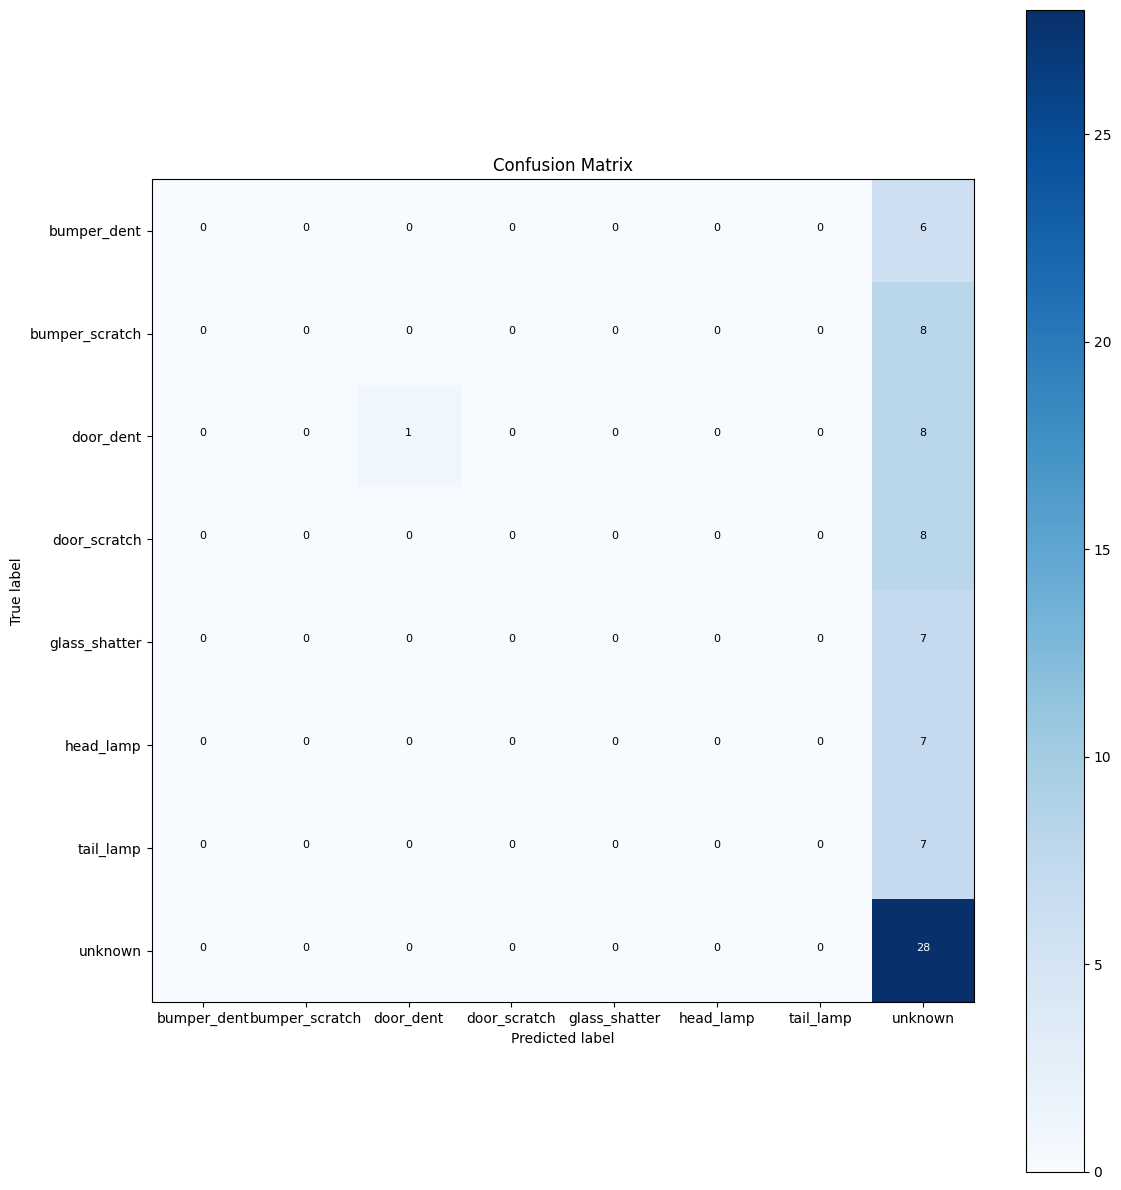

In [18]:
from utils import get_y_true_y_pred, make_confusion_matrix

# Baseline model_1
y_true_base, y_pred_base = get_y_true_y_pred(model_1, test_ds)
fig_base, ax_base = make_confusion_matrix(
    y_true=y_true_base,
    y_pred=y_pred_base,
    classes=class_names,
    figsize=(12, 12),
    text_size=8,
    norm=False,
    savefig=False,
    filename="model_1.png"
)


### 2_ base_model_with_augmentation_and_fine_tuning  
adding augmentation and unfreeze some layers to be trainable

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import mlflow
import mlflow.tensorflow

model_name = "M2_efficientnet_b0_aug_last10_only"

# Data augmentation layer
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
], name="data_augmentation")

with mlflow.start_run(run_name=model_name):
    mlflow.tensorflow.autolog()

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
    )
    
    # Fine-tune last 10 layers only
    base_model.trainable = True
    for layer in base_model.layers[:-10]:
        layer.trainable = False
    
    # Freeze BatchNorm layers for stability
    for layer in base_model.layers[-10:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # Keep BN in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.2, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

    model_2 = tf.keras.Model(inputs, outputs, name=model_name)

    model_2.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),  # Low LR for fine-tuning
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0,
    )

    history_2 = model_2.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stopping],
    )
    # # Manually log the model
    # mlflow.tensorflow.log_model(model_2, artifact_path="model")

In [ ]:
from utils import get_y_true_y_pred, make_confusion_matrix

# Baseline model_1
y_true_base, y_pred_base = get_y_true_y_pred(model_2, test_ds)
fig_base, ax_base = make_confusion_matrix(
    y_true=y_true_base,
    y_pred=y_pred_base,
    classes=class_names,
    figsize=(12, 12),
    text_size=8,
    norm=False,
    savefig=False,
    filename="model_2.png"
)

### 3_model_mobilenetv3_large_ft20_with_augmentation_and_fine_tuning  


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import mlflow
import mlflow.tensorflow

model_name = "M3_mobilenetv3_large_ft20"

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
], name="data_augmentation")

with mlflow.start_run(run_name=model_name):
    mlflow.tensorflow.autolog()

    base_model = tf.keras.applications.MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
    )

    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    for layer in base_model.layers[-20:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.2, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

    model_3 = tf.keras.Model(inputs, outputs, name=model_name)

    model_3.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0,
    )

    history_3 = model_3.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stopping],
    )
    # # Manually log the model
    # mlflow.tensorflow.log_model(model_3, artifact_path="model")

In [ ]:
from utils import get_y_true_y_pred, make_confusion_matrix

# Baseline model_1
y_true_base, y_pred_base = get_y_true_y_pred(model_3, test_ds)
fig_base, ax_base = make_confusion_matrix(
    y_true=y_true_base,
    y_pred=y_pred_base,
    classes=class_names,
    figsize=(12, 12),
    text_size=8,
    norm=False,
    savefig=False,
    filename="model_3.png"
)

### 4_model_resnet50_with_augmentation_and_fine_tuning  


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import mlflow
import mlflow.tensorflow

model_name = "M4_resnet50_ft20"

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
], name="data_augmentation")

with mlflow.start_run(run_name=model_name):
    mlflow.tensorflow.autolog()

    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
    )

    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    for layer in base_model.layers[-20:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.2, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

    model_4 = tf.keras.Model(inputs, outputs, name=model_name)

    model_4.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0,
    )

    history_4 = model_4.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stopping],
    )

    # # Manually log the model
    # mlflow.tensorflow.log_model(model_4, artifact_path= "model")

In [ ]:
from utils import get_y_true_y_pred, make_confusion_matrix

# Baseline model_1
y_true_base, y_pred_base = get_y_true_y_pred(model_4, test_ds)
fig_base, ax_base = make_confusion_matrix(
    y_true=y_true_base,
    y_pred=y_pred_base,
    classes=class_names,
    figsize=(12, 12),
    text_size=8,
    norm=False,
    savefig=False,
    filename="model_4.png"
)

### 5_model_yolo_detection 


In [ ]:
from pathlib import Path
from ultralytics import YOLO

# ============================================================================
# Setup paths
# ============================================================================
PROJECT_ROOT = Path.cwd().resolve()
YOLO_RUNS_DIR = PROJECT_ROOT / "runs" / "classify"
DATASET_ROOT = PROJECT_ROOT / "dataset"

# Create output directory
YOLO_RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# Training
# ============================================================================
model_name = "M5_yolo11s_cls"

# Load pretrained model
model_5 = YOLO("yolo11s-cls.pt")

# Train
results = model_5.train(
    data=str(DATASET_ROOT),
    epochs=100,
    imgsz=224,
    batch=32,
    device=0,
    patience=5,
    optimizer="Adam",
    lr0=1e-4,
    
    # Data augmentation
    fliplr=0.5,
    flipud=0.0,
    degrees=36,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    
    # Output settings
    project=str(YOLO_RUNS_DIR),
    name=model_name,
    exist_ok=True,
    verbose=True,
    plots=True,
)

# ============================================================================
# Results
# ============================================================================
print("\n" + "="*80)
print("✓ Training complete!")
print(f"✓ Model saved to: {model_5.trainer.save_dir}")
print(f"✓ Best weights: {model_5.trainer.best}")
print("="*80)

# Print final metrics
metrics = getattr(results, "results_dict", {})
if metrics:
    print("\nFinal Metrics:")
    if "metrics/accuracy_top1" in metrics:
        print(f"  Top-1 Accuracy: {metrics['metrics/accuracy_top1']:.4f}")
    if "metrics/accuracy_top5" in metrics:
        print(f"  Top-5 Accuracy: {metrics['metrics/accuracy_top5']:.4f}")

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def show_yolo_test_confusion_matrix(
    model_path="runs/classify/M5_yolo11n_cls/weights/best.pt",
    test_dir="dataset/test",
    class_names=None,
    figsize=(12, 12),
    text_size=8,
    norm=False,
    savefig=False,
    filename="yolo_test_confusion_matrix.png",
):
    model = YOLO(model_path)
    test_dir = Path(test_dir)

    if class_names is None:
        class_names = [p.name for p in sorted(test_dir.iterdir()) if p.is_dir()]

    class_to_idx = {name: i for i, name in enumerate(class_names)}
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_paths = []
    y_true = []

    for class_name in class_names:
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue

        files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in exts])
        image_paths.extend([str(p) for p in files])
        y_true.extend([class_to_idx[class_name]] * len(files))

    results = model(image_paths, verbose=False)
    y_pred = np.array([int(r.probs.top1) for r in results])
    y_true = np.array(y_true)

    fig, ax = make_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        classes=class_names,
        figsize=figsize,
        text_size=text_size,
        norm=norm,
        savefig=savefig,
        filename=filename,
    )

    acc = (y_true == y_pred).mean()
    print(f"Test accuracy: {acc:.4f}")

    plt.show()
    return y_true, y_pred, fig, ax

%matplotlib inline
y_true, y_pred, fig, ax = show_yolo_test_confusion_matrix(
    model_path="runs/classify/M5_yolo11n_cls/weights/best.pt",
    test_dir="dataset/test",
    class_names=class_names,
)

In [ ]:
# # Save in the new Keras format (.keras)
# model_1.save("model_1.keras")
# model_2.save("model_2.keras")
# model_3.save("model_3.keras")
# model_4.save("model_4.keras")


In [19]:
import tensorflow as tf
import numpy as np
from pathlib import Path

# Model paths
model_paths = {
    "M1 (EfficientNetB0 Baseline)": "model_1.keras",
    "M2 (EfficientNetB0 + Aug + FT)": "model_2.keras",
    "M3 (MobileNetV3 + Aug + FT)": "model_3.keras",
    "M4 (ResNet50 + Aug + FT)": "model_4.keras"
}

# Load and evaluate all models
results = {}

for model_name, model_path in model_paths.items():
    if Path(model_path).exists():
        print(f"\n{'='*60}")
        print(f"Evaluating: {model_name}")
        print(f"{'='*60}")
        
        # Load model
        model = tf.keras.models.load_model(model_path)
        
        # Evaluate on test set
        test_loss, test_acc = model.evaluate(test_ds, verbose=1)
        
        # Store results
        results[model_name] = {
            "loss": test_loss,
            "accuracy": test_acc
        }
        
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    else:
        print(f"❌ Model not found: {model_path}")

# Print comparison table
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"{'Model':<40} {'Accuracy':<10} {'Loss':<10}")
print(f"{'-'*60}")

for model_name, metrics in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"{model_name:<40} {metrics['accuracy']*100:>6.2f}%   {metrics['loss']:>8.4f}")

# Find best model
best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"\n🏆 Best Model: {best_model[0]}")
print(f"   Accuracy: {best_model[1]['accuracy']*100:.2f}%")


Evaluating: M1 (EfficientNetB0 Baseline)
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.3625 - loss: 1.8034
Test Loss: 1.8034
Test Accuracy: 0.3625 (36.25%)

Evaluating: M2 (EfficientNetB0 + Aug + FT)
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.8250 - loss: 0.5425
Test Loss: 0.5425
Test Accuracy: 0.8250 (82.50%)

Evaluating: M3 (MobileNetV3 + Aug + FT)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7875 - loss: 0.6239
Test Loss: 0.6239
Test Accuracy: 0.7875 (78.75%)

Evaluating: M4 (ResNet50 + Aug + FT)
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.8500 - loss: 0.6065
Test Loss: 0.6065
Test Accuracy: 0.8500 (85.00%)

MODEL COMPARISON SUMMARY
Model                                    Accuracy   Loss      
------------------------------------------------------------
M4 (ResNet50 + Aug + FT)                  85.00%     0.6065
M2 (EfficientNetB0 + Aug + FT)            82.50%     0.5425
M3 (MobileNetV3 + Aug + FT)               78.75%     0.6239
M1 (EfficientNetB0

## Results


                    MODEL EVALUATION

Evaluating: M1 - EfficientNetB0 Baseline
✓ Test Accuracy: 36.25%
✓ Test Loss: 1.8034

Evaluating: M2 - EfficientNetB0 + Aug + FT
✓ Test Accuracy: 82.50%
✓ Test Loss: 0.5425

Evaluating: M3 - MobileNetV3 + Aug + FT
✓ Test Accuracy: 78.75%
✓ Test Loss: 0.6239

Evaluating: M4 - ResNet50 + Aug + FT
✓ Test Accuracy: 85.00%
✓ Test Loss: 0.6065

Evaluating: M5 - YOLO11s-cls
✓ Test Accuracy: 87.50%

                    COMPARISON SUMMARY
Model                                         Accuracy     Loss      
----------------------------------------------------------------------
M5 - YOLO11s-cls                              87.50%       N/A       
M4 - ResNet50 + Aug + FT                      85.00%       0.6065    
M2 - EfficientNetB0 + Aug + FT                82.50%       0.5425    
M3 - MobileNetV3 + Aug + FT                   78.75%       0.6239    
M1 - EfficientNetB0 Baseline                  36.25%       1.8034    

🏆 BEST MODEL: M5 - YOLO11s-cls
   Ac

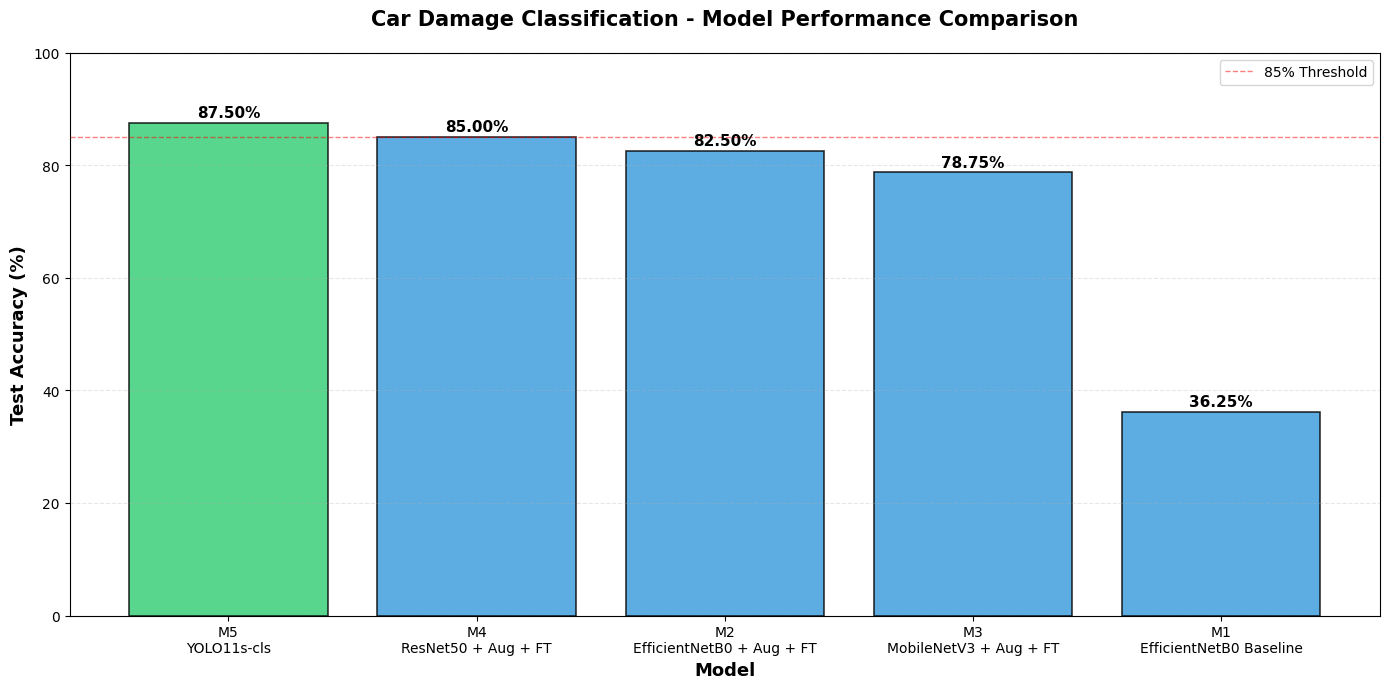


                  PER-CLASS ACCURACY

M5 - YOLO11s-cls:
--------------------------------------------------
  bumper_dent         : 100.00%
  bumper_scratch      : 100.00%
  door_dent           :  66.67%
  door_scratch        :  87.50%
  glass_shatter       :  85.71%
  head_lamp           :  71.43%
  tail_lamp           :  85.71%
  unknown             :  92.86%

M4 - ResNet50 + Aug + FT:
--------------------------------------------------
  bumper_dent         :  83.33%
  bumper_scratch      : 100.00%
  door_dent           :  44.44%
  door_scratch        : 100.00%
  glass_shatter       :  85.71%
  head_lamp           :  71.43%
  tail_lamp           :  85.71%
  unknown             :  92.86%

M2 - EfficientNetB0 + Aug + FT:
--------------------------------------------------
  bumper_dent         : 100.00%
  bumper_scratch      :  75.00%
  door_dent           :  44.44%
  door_scratch        :  87.50%
  glass_shatter       : 100.00%
  head_lamp           :  71.43%
  tail_lamp           :  8

In [20]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd

# Model paths
model_configs = {
    "M1 - EfficientNetB0 Baseline": {
        "path": "model_1.keras",
        "type": "keras"
    },
    "M2 - EfficientNetB0 + Aug + FT": {
        "path": "model_2.keras",
        "type": "keras"
    },
    "M3 - MobileNetV3 + Aug + FT": {
        "path": "model_3.keras",
        "type": "keras"
    },
    "M4 - ResNet50 + Aug + FT": {
        "path": "model_4.keras",
        "type": "keras"
    },
    "M5 - YOLO11s-cls": {
        "path": "runs/classify/M5_yolo11s_cls/weights/best.pt",  # Or wherever your model_5.pt is
        "type": "yolo"
    }
}

def evaluate_keras_model(model_path, test_ds):
    """Evaluate Keras model on test dataset"""
    model = tf.keras.models.load_model(model_path)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    # Get predictions for detailed metrics
    y_true = []
    y_pred = []
    
    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())
    
    return {
        "accuracy": test_acc,
        "loss": test_loss,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred)
    }

def evaluate_yolo_model(model_path, test_dir, class_names):
    """Evaluate YOLO model on test dataset"""
    model = YOLO(model_path)
    
    # Collect all test images
    test_dir = Path(test_dir)
    image_paths = []
    y_true = []
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = test_dir / class_name
        if class_dir.exists():
            images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
            image_paths.extend([str(p) for p in images])
            y_true.extend([class_idx] * len(images))
    
    # Run predictions
    results = model(image_paths, verbose=False)
    y_pred = [int(r.probs.top1) for r in results]
    
    # Calculate accuracy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    accuracy = (y_true == y_pred).mean()
    
    return {
        "accuracy": accuracy,
        "loss": None,  # YOLO doesn't return loss during inference
        "y_true": y_true,
        "y_pred": y_pred
    }

# ============================================
# EVALUATE ALL MODELS
# ============================================
print("="*70)
print(" " * 20 + "MODEL EVALUATION")
print("="*70)

results = {}

for model_name, config in model_configs.items():
    model_path = config["path"]
    
    if not Path(model_path).exists():
        print(f"\n❌ Model not found: {model_path}")
        continue
    
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*70}")
    
    try:
        if config["type"] == "keras":
            results[model_name] = evaluate_keras_model(model_path, test_ds)
            print(f"✓ Test Accuracy: {results[model_name]['accuracy']*100:.2f}%")
            print(f"✓ Test Loss: {results[model_name]['loss']:.4f}")
            
        elif config["type"] == "yolo":
            results[model_name] = evaluate_yolo_model(
                model_path, 
                "dataset/test", 
                class_names
            )
            print(f"✓ Test Accuracy: {results[model_name]['accuracy']*100:.2f}%")
        
    except Exception as e:
        print(f"❌ Error evaluating {model_name}: {str(e)}")

# ============================================
# COMPARISON SUMMARY
# ============================================
print(f"\n{'='*70}")
print(" " * 20 + "COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"{'Model':<45} {'Accuracy':<12} {'Loss':<10}")
print(f"{'-'*70}")

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

for model_name, metrics in sorted_results:
    acc_str = f"{metrics['accuracy']*100:.2f}%"
    loss_str = f"{metrics['loss']:.4f}" if metrics['loss'] is not None else "N/A"
    print(f"{model_name:<45} {acc_str:<12} {loss_str:<10}")

# Best model
if results:
    best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"\n{'='*70}")
    print(f"🏆 BEST MODEL: {best_model[0]}")
    print(f"   Accuracy: {best_model[1]['accuracy']*100:.2f}%")
    print(f"{'='*70}")

# ============================================
# SAVE RESULTS TO CSV
# ============================================
df_results = pd.DataFrame([
    {
        "Model": name,
        "Accuracy (%)": metrics['accuracy'] * 100,
        "Loss": metrics['loss'] if metrics['loss'] is not None else np.nan
    }
    for name, metrics in sorted_results
])

df_results.to_csv("model_comparison_results.csv", index=False)
print(f"\n✓ Results saved to 'model_comparison_results.csv'")

# ============================================
# VISUALIZATION
# ============================================
fig, ax = plt.subplots(figsize=(14, 7))

model_names = [name.replace(" - ", "\n") for name, _ in sorted_results]
accuracies = [metrics['accuracy'] * 100 for _, metrics in sorted_results]

colors = ['#2ecc71' if acc == max(accuracies) else '#3498db' for acc in accuracies]
bars = ax.bar(range(len(model_names)), accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Car Damage Classification - Model Performance Comparison', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=85, color='red', linestyle='--', linewidth=1, alpha=0.5, label='85% Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Visualization saved to 'model_comparison.png'")
plt.show()

# ============================================
# PER-CLASS ACCURACY (Optional)
# ============================================
print(f"\n{'='*70}")
print(" " * 18 + "PER-CLASS ACCURACY")
print(f"{'='*70}")

for model_name, metrics in sorted_results:
    y_true = metrics['y_true']
    y_pred = metrics['y_pred']
    
    print(f"\n{model_name}:")
    print("-" * 50)
    
    for idx, class_name in enumerate(class_names):
        mask = y_true == idx
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == y_true[mask]).mean() * 100
            print(f"  {class_name:<20}: {class_acc:>6.2f}%")

### Show the real result

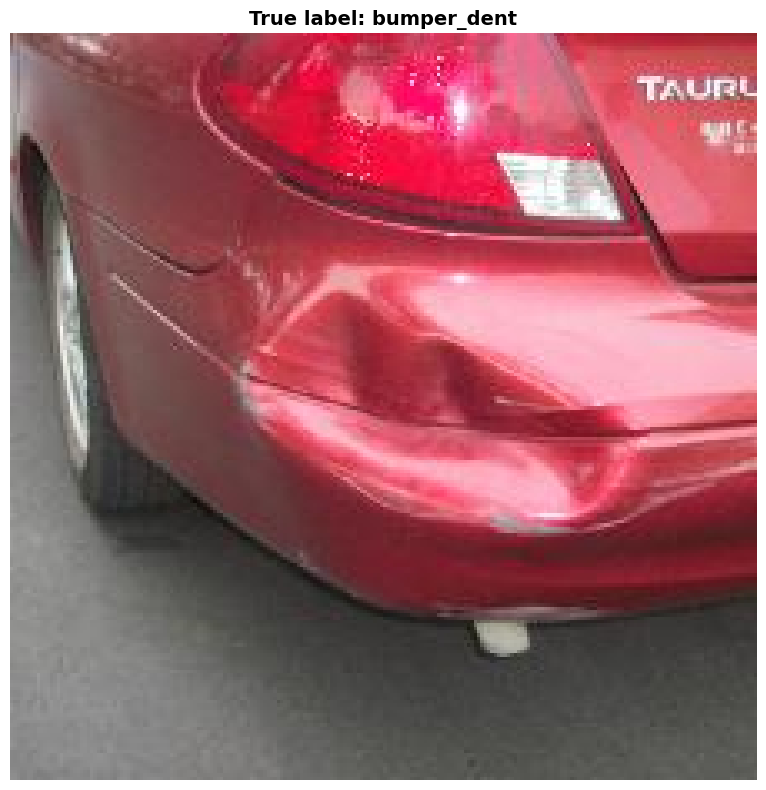

Image: 1271.jpeg
True label: bumper_dent

model_1:
  Predicted : unknown ✗
  Confidence: 0.2431 (24.31%)

model_2:
  Predicted : bumper_dent ✓
  Confidence: 0.9813 (98.13%)

model_3:
  Predicted : bumper_dent ✓
  Confidence: 0.9999 (99.99%)

model_4:
  Predicted : bumper_dent ✓
  Confidence: 0.9993 (99.93%)


model_5:
  Predicted : bumper_dent ✓
  Confidence: 0.9555 (95.55%)



In [41]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from ultralytics import YOLO

def compare_all_models_on_random_test_image(
    test_dir="dataset/test",
    class_names=None,
    keras_model_paths=None,
    yolo_model_path="model_5.pt",
    figsize=(8, 8),
):
    if keras_model_paths is None:
        keras_model_paths = [
            "model_1.keras",
            "model_2.keras",
            "model_3.keras",
            "model_4.keras",
        ]

    test_dir = Path(test_dir)
    
    if class_names is None:
        class_names = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])

    # Collect all test image paths
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    all_image_paths = []
    all_true_labels = []

    for class_name in class_names:
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue

        files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in exts])
        all_image_paths.extend(files)
        all_true_labels.extend([class_name] * len(files))

    # Pick random image
    idx = random.randint(0, len(all_image_paths) - 1)
    img_path = all_image_paths[idx]
    true_label = all_true_labels[idx]

    # ✅ Load original image (keep as uint8 0-255)
    image_original = np.array(Image.open(img_path).convert("RGB").resize((224, 224)))

    # Show original image
    plt.figure(figsize=figsize)
    plt.imshow(image_original)
    plt.title(f"True label: {true_label}", fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Image: {img_path.name}")
    print(f"True label: {true_label}")
    print("=" * 60)

    # ✅ FIX: Keep as float32 but DON'T divide by 255
    # Models have Rescaling layer inside - they expect 0-255 range
    image_for_keras = image_original.astype(np.float32)  # Still 0-255!
    image_batch = np.expand_dims(image_for_keras, axis=0)

    # Keras models
    for model_path in keras_model_paths:
        if not Path(model_path).exists():
            print(f"⚠️ {model_path} not found, skipping...")
            continue
            
        model = tf.keras.models.load_model(model_path)
        preds = model.predict(image_batch, verbose=0)
        pred_idx = int(np.argmax(preds[0]))
        pred_conf = float(np.max(preds[0]))
        pred_name = class_names[pred_idx]
        
        # Check if correct
        is_correct = "✓" if pred_name == true_label else "✗"

        print(f"\n{Path(model_path).stem}:")
        print(f"  Predicted : {pred_name} {is_correct}")
        print(f"  Confidence: {pred_conf:.4f} ({pred_conf*100:.2f}%)")

    print("\n" + "=" * 60)

    # YOLO model (also expects raw uint8 or float32 0-255)
    if Path(yolo_model_path).exists():
        yolo_model = YOLO(yolo_model_path)
        yolo_result = yolo_model(image_original, verbose=False)[0]
        yolo_pred_idx = int(yolo_result.probs.top1)
        yolo_conf = float(yolo_result.probs.top1conf.cpu().item())
        yolo_pred_name = yolo_result.names[yolo_pred_idx]
        
        is_correct = "✓" if yolo_pred_name == true_label else "✗"

        print(f"\n{Path(yolo_model_path).stem}:")
        print(f"  Predicted : {yolo_pred_name} {is_correct}")
        print(f"  Confidence: {yolo_conf:.4f} ({yolo_conf*100:.2f}%)")
    else:
        print(f"\n⚠️ {yolo_model_path} not found")

    print("\n" + "=" * 60)


# Run comparison
compare_all_models_on_random_test_image(
    test_dir="dataset/test",
    class_names=class_names,
    keras_model_paths=[
        "model_1.keras",
        "model_2.keras",
        "model_3.keras",
        "model_4.keras",
    ],
    yolo_model_path="model_5.pt",
)